# Overview of anomalies

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from anomaly.utils import VelocityFilter
from anomaly.utils import AnomalyOverlapAnalyzer
from autoencoders.ae import AutoEncoder

from sdss.metadata import MetaData

meta = MetaData()

# Constants

In [3]:
mse_cols = ['mse', 'mse_filter_250', 'mse_97', 'mse_filter_250_97']
mse_rel_cols = ['mse_rel', 'mse_filter_250_rel', 'mse_97_rel', 'mse_filter_250_97_rel']

In [4]:
mse_family = ['mse', 'mse_97', 'mse_filter_250', 'mse_filter_250_97']
chi_sq_family = ['mse_rel', 'mse_97_rel', 'mse_filter_250_rel', 'mse_filter_250_97_rel']

# Custom functions

## IDs top anomalies

In [5]:
def get_ids(score, df, quantile=99):

    quantile*=0.01

    thresh = df[score].quantile(quantile)
    
    ids = set(df[df[score] > thresh].index)

    return ids

## Figures

In [7]:
def anomaly_plot(wave, specs, objids, ranks, save_to):

    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    for spec, objid, rank in zip(specs, objids, ranks):

        print(f'Rank {rank:03d}', end='\r')

        ax.clear()

        ax.plot(wave, spec, color="black", label=f'Rank: {rank}')

        ax.minorticks_on()
        ax.set_xlabel(r"$\lambda$ [nm]")
        ax.set_title(f"Object ID: {objid}")

        ax.legend(
            loc='upper left',
            frameon=False,
        )

        fig.savefig(
            f"{save_to}/{rank:03d}_{objid}.jpeg",
            bbox_inches='tight'
        )

    plt.close(fig)

# Config

## Directories

In [8]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
bin_ids = [f"bin_{i:02d}" for i in range(4)]
#
ch_4_dir = f"{thesis_dir}/chapters/04_figures"

## Data

In [9]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)

In [59]:
bin_id = 'bin_03'
score_03_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)
n_spec = score_03_df.shape[0]
n_top_1_pct = int(n_spec*0.01)
n_top_1_pct

1818

## Append rank per score

In [65]:
rank = np.arange(score_03_df.shape[0])
score_03_rank_df = score_03_df.copy()
# score_rank_df
for col in score_03_df.columns:

    index_sorted = score_03_df.sort_values(
        by=col, ascending=False
    ).index

    score_03_rank_df.loc[index_sorted, f'rank_{col}'] = rank
    score_03_rank_df[f'rank_{col}'].astype(int)

In [66]:
score_03_df.columns

Index(['mse', 'mse_97', 'mse_filter_250', 'mse_filter_250_97', 'mse_rel',
       'mse_97_rel', 'mse_filter_250_rel', 'mse_filter_250_97_rel'],
      dtype='object')

In [67]:
score = 'mse_97'
score_03_rank_df[[score, f'rank_{score}']].sort_values(
        by=score, ascending=True
    )

,mse_97,rank_mse_97
specobjid,,
1874672048211519488,0.717539,181849.0
2179856624724764672,0.725384,181848.0
2103285260375582720,0.750020,181847.0
2235035342581295104,0.750198,181846.0
3109855465517901824,0.757616,181845.0
...,...,...
3090596414779058176,43.832197,4.0
1379310995071068160,45.775212,3.0
1547052494423615488,48.517104,2.0


## Model

In [11]:
ae_03 = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/bin_03/winner",
)

In [12]:
ae_03.get_architecture_and_model_str()

['256_128_64_12_64_128_256', 'infoVae_rec_3776_alpha_0_lambda_9']

# Figures top 1%

```python
all_scores = mse_cols + mse_rel_cols
plt.ioff()

for score in all_scores:

    specids_top_1 = score_03_df[score].sort_values(
        ascending=False
    ).index.to_numpy()[:n_top_1_pct]

    ranks = np.zeros(n_top_1_pct).astype(int)

    specs_top_1 = np.empty((n_top_1_pct, wave.size))

    for i, objid in enumerate(specids_top_1):

        spec_idx = specobjid_to_idx(
            objid, idx_id_spec
        )

        specs_top_1[i, :] = spectra[spec_idx, :]

        ranks[i] = i

    -----------------------------------------------------------

    save_to = f"{scores_dir}/bin_03/figs/{score}"

    os.makedirs(save_to, exist_ok=True)

    anomaly_plot(
        wave_nm, specs=specs_top_1,
        objids=specids_top_1, ranks=ranks,
        save_to=save_to
    )
```

# No free lunch theorem

## IDs per score

In [100]:
ids_top_dict = {}

all_scores = mse_cols + mse_rel_cols

for score in all_scores:

    ids_top_dict[score] = get_ids(
        score, score_03_df.copy(),
        quantile=99.5
    )

# Distinct IDs

## MSE family

In [101]:
unique_mse_ids_dict = AnomalyOverlapAnalyzer.get_unique_ids(
    ids_dict=ids_top_dict, score_list=mse_cols
)
for target in mse_cols:
    print(f"Unique to {target}: {len(unique_mse_ids_dict[target])}")

Unique to mse: 23
Unique to mse_filter_250: 26
Unique to mse_97: 6
Unique to mse_filter_250_97: 4


In [102]:
score = 'mse'
unique_mse_ids = list(unique_mse_ids_dict[score])
score_03_rank_df.loc[
    unique_mse_ids, [score, f'rank_{score}']
].sort_values(by=score, ascending=False)

,mse,rank_mse
specobjid,,
1943453375177713664,72.866039,692.0
2527787198460225536,72.176748,721.0
2409583645288327168,68.551013,839.0
2368932776163436544,68.523769,841.0
1775595339017906176,68.497094,842.0
531489385137334272,68.396077,845.0
2423075477863294976,68.333235,846.0
2181002316813985792,68.217378,854.0
707178426141796352,68.211349,856.0


## Chi family

In [103]:
unique_chi_ids_dict = AnomalyOverlapAnalyzer.get_unique_ids(
    ids_dict=ids_top_dict, score_list=mse_rel_cols
)
for target in mse_rel_cols:
    print(f"Unique to {target}: {len(unique_chi_ids_dict[target])}")

Unique to mse_rel: 51
Unique to mse_filter_250_rel: 36
Unique to mse_97_rel: 5
Unique to mse_filter_250_97_rel: 6


In [104]:
score = 'mse_97_rel'
unique_mse_ids = list(unique_chi_ids_dict[score])
score_03_rank_df.loc[
    unique_mse_ids, [score, f'rank_{score}']
].sort_values(by=score, ascending=False)

,mse_97_rel,rank_mse_97_rel
specobjid,,
435860458071681024,33.955428,894.0
417849637790050304,33.948427,900.0
2238334152980064256,33.922378,902.0
2045826440917706752,33.860385,907.0
1650572338812446720,33.857332,909.0


## All scores

In [105]:
all_scores = mse_cols + mse_rel_cols

unique_all_ids_dict = AnomalyOverlapAnalyzer.get_unique_ids(
    ids_dict=ids_top_dict, score_list=all_scores
)
for target in all_scores:
    print(f"Unique to {target}: {len(unique_all_ids_dict[target])}")

Unique to mse: 14
Unique to mse_filter_250: 16
Unique to mse_97: 2
Unique to mse_filter_250_97: 2
Unique to mse_rel: 50
Unique to mse_filter_250_rel: 33
Unique to mse_97_rel: 5
Unique to mse_filter_250_97_rel: 5


In [106]:
score = 'mse_97'
unique_mse_ids = list(unique_all_ids_dict[score])
score_03_rank_df.loc[
    unique_mse_ids, [score, f'rank_{score}']
].sort_values(by=score, ascending=False)

,mse_97,rank_mse_97
specobjid,,
2375750016674326528,28.093621,906.0
2023356832298330112,28.091106,907.0


## Figures

In [84]:
all_scores = mse_cols + mse_rel_cols
plt.ioff()

for score in all_scores:

    specids = list(unique_all_ids_dict[score])
    specids = np.array(specids, dtype=int)

    ranks = score_03_rank_df.loc[
        specids, f'rank_{score}'
    ].to_numpy().astype(int)

    specs = np.empty((len(specids), wave.size))

    for i, objid in enumerate(specids):

        spec_idx = specobjid_to_idx(
            objid, idx_id_spec
        )

        specs[i, :] = spectra[spec_idx, :]

    # -----------------------------------------------------------

    save_to = f"{scores_dir}/bin_03/figs/unique_all/{score}"

    os.makedirs(save_to, exist_ok=True)

    anomaly_plot(
        wave_nm, specs=specs,
        objids=specids, ranks=ranks,
        save_to=save_to
    )

# Common IDs

## MSE family

In [107]:
common_mse_ids = AnomalyOverlapAnalyzer.get_core_common_ids(
    ids_dict=ids_top_dict, score_list=mse_cols
)
print(f"Number of objects found by ALL {len(mse_cols)} scores: {len(common_mse_ids)}")

Number of objects found by ALL 4 scores: 387


In [108]:
387/909

0.42574257425742573

## Chi Family

In [18]:
common_chi_ids = AnomalyOverlapAnalyzer.get_core_common_ids(
    ids_dict=ids_top_dict, score_list=mse_rel_cols
)
print(f"Number of objects found by ALL {len(mse_rel_cols)} scores: {len(common_chi_ids)}")

Number of objects found by ALL 4 scores: 1203


## All scores

In [ ]:
all_scores = mse_cols + mse_rel_cols 
common_all_ids = AnomalyOverlapAnalyzer.get_core_common_ids(
    ids_dict=ids_top_dict, score_list=all_scores
)
print(f"Number of objects found by ALL {len(all_scores)} scores: {len(common_all_ids)}")
# Number of objects found by ALL 8 scores: 458

Number of objects found by ALL 8 scores: 458


In [94]:
score_03_df.loc[637325355518027776]

mse                      11.333066
mse_97                    7.086562
mse_filter_250           11.285156
mse_filter_250_97         7.024457
mse_rel                  11.874136
mse_97_rel                8.380834
mse_filter_250_rel       11.751321
mse_filter_250_97_rel     8.279176
Name: 637325355518027776, dtype: float64

In [95]:
score_03_rank_df.loc[637325355518027776]

mse                              11.333066
mse_97                            7.086562
mse_filter_250                   11.285156
mse_filter_250_97                 7.024457
mse_rel                          11.874136
mse_97_rel                        8.380834
mse_filter_250_rel               11.751321
mse_filter_250_97_rel             8.279176
rank_mse                      46977.000000
rank_mse_97                   49118.000000
rank_mse_filter_250           46372.000000
rank_mse_filter_250_97        49287.000000
rank_mse_rel                  45241.000000
rank_mse_97_rel               48394.000000
rank_mse_filter_250_rel       44801.000000
rank_mse_filter_250_97_rel    48691.000000
Name: 637325355518027776, dtype: float64

In [92]:
final_meta_df.loc[637325355518027776]

mjd                   52238
plate                   566
fiberid                 240
run2d                    26
ra                 136.1286
dec                3.219783
z                  0.122018
zErr               0.000026
zWarning                  0
class                GALAXY
subClass                NaN
z_noqso                   0
zErr_noqso                0
zWarning_noqso            0
targetType          SCIENCE
programname          legacy
instrument             SDSS
snMedian           23.91221
ABSSB             undefined
BROAD             undefined
ebv                0.041933
indexArray           9108.0
Name: 637325355518027776, dtype: object

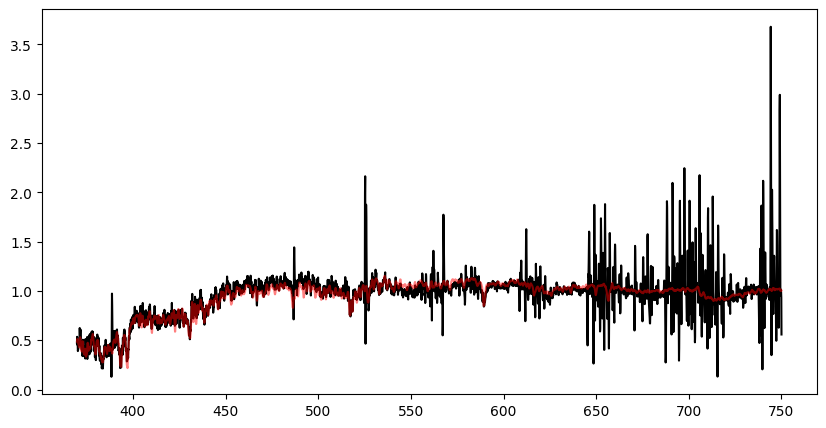

In [99]:
objid = 637325355518027776
spec_idx = specobjid_to_idx(
        objid, idx_id_spec
)
spec = spectra[spec_idx]
rec_spec = ae_03.reconstruct(spec).reshape(-1)
fig, ax = plt.subplots(1,1, figsize=(10, 5))

ax.plot(wave_nm, spec, color='black')
ax.plot(wave_nm, rec_spec, color='red', alpha=0.5)

plt.show()

In [110]:
mse_score_artifact = np.sqrt(np.sum((spec - rec_spec)**2))
mse_score_artifact

10.4833765

In [113]:
from anomaly.metrics import Reconstruction
mse_standard = Reconstruction().mse(spec, rec_spec)
mse_standard

array([[10.48337644]])

### Figures

In [89]:
all_scores = mse_cols + mse_rel_cols
plt.ioff()


specids = list(common_all_ids)
specids = np.array(specids, dtype=int)

ranks = score_03_rank_df.loc[
    specids, 'rank_mse'
].to_numpy().astype(int)

specs = np.empty((len(specids), wave.size))

for i, objid in enumerate(specids):

    spec_idx = specobjid_to_idx(
        objid, idx_id_spec
    )

    specs[i, :] = spectra[spec_idx, :]

# -----------------------------------------------------------

save_to = f"{scores_dir}/bin_03/figs/common_all"

os.makedirs(save_to, exist_ok=True)

anomaly_plot(
    wave_nm, specs=specs,
    objids=specids, ranks=ranks,
    save_to=save_to
)

# MSE family
Show anomalies that are different for each score
in the family. This to highlight differences.
Plot 4 spectra for score such that each spectra
is unique to each score, that is, for a set
of 4 spectra in mse, they should not be present
in the remaining variations, and so on.

## Standard

In [36]:
score_a = 'mse'
score_b = 'mse_filter_250'
df = score_03_df.copy()
(
    ids_a, ids_b,
    common_ids,
    only_in_a,
    only_in_b
) = overlap_pair_scores(
    score_a, score_b,
    df,
    quantile=99
)
len(only_in_a), len(only_in_b), list(only_in_a)

(74,
 74,
 [1351109619786737664,
  1338745061776582656,
  319829548298430464,
  522529189216151552,
  2039044647862429696,
  3096386718073382912,
  619313151350958080,
  609131123921938432,
  948011884592785408,
  443751929948956672,
  2788938249970673664,
  1473871194116614144,
  2443351846685796352,
  661055011911919616,
  588922925961209856,
  1959077433948792832,
  2417357461217372160,
  1339862440501864448,
  823174435296012288,
  1640542319419615232,
  1039377453040035840,
  1092167755219625984,
  1463831556983384064,
  2724689937738786816,
  645160476837177344,
  1946849778692286464,
  957124086570444800,
  1891553953015949312,
  556219599998183424,
  3346345024378923008,
  2445509644211218432,
  699294652422973440,
  1146269504087549952,
  1134952506367961088,
  3118823631723980800,
  2912845515181811712,
  2375750016674326528,
  3247253462064326656,
  3097522238723745792,
  2528826504427628544,
  2356593506350295040,
  569752665785919488,
  1917567034275686400,
  8828768149412

## Trimmed

## Trimmed

## Filtered-Trimmed

# Chi family

## Standard

## Filtered

## Trimmed

## Filtered-Trimmed